In [21]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn.init import uniform_
import torch.nn.functional as F
from tqdm import trange
import numpy as np
import math
from scipy.ndimage import gaussian_filter1d

from torch.nn.init import uniform_, xavier_uniform_
from random import randint
from torch import optim

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [22]:
import sys
import os
# Add parent directory to path so we can import multi_task_training as a package
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

In [23]:
from multi_task_training.rnn_model import PLRNN, train_multitask

## define tasks

In [ ]:
from tasks import DelayedResponse, ReactionTime, CategoryDecision, DelayedMatchToSample, GoNogo, MemoryArithmetics, Arithmetics, ContextIntegration, PredictiveTracking, NoiseCleaner, NextPositionPrediction, CopyTask
from dataset import MultiTaskDataset, MultiTaskDataset_v2, collate_fn
from torch.utils.data import DataLoader
# Set random seeds
torch.manual_seed(0)
np.random.seed(0)
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

In [ ]:

# Duration parameters (in timesteps)
#duration_params = {
#    'context': (5, 15),
#    'stimulus': (10, 30),
#    'delay': (10, 30),
#    'response': (5, 15)
#}

duration_params = {
    'context': (5, 10),      # Shorter
    'stimulus': (10, 15),    # Shorter, less variable
    'delay': (10, 15),       # Shorter delays
    'response': (5, 10)
}

duration_params_hard = {
    'context': (10, 20),     # Longer, more variable
    'stimulus': (10, 40),    # More variable stimulus
    'delay': (20, 50),       # Longer memory requirement
    'response': (10, 20)
}

# Create tasks
tasks = [
    # NextPositionPrediction(duration_params),
    # PredictiveTracking(duration_params),
    # NoiseCleaner(duration_params, noise_level=0.6),
    # Arithmetics(duration_params, mode='multiply')
    # MemoryArithmetics(duration_params, mode='subtract'),
    # # DelayedDiscrimination(duration_params, mode='pro'),
    # # DelayedDiscrimination(duration_params, mode='anti'),
    # DelayedResponse(duration_params, mode='pro'),
    # DelayedResponse(duration_params, mode='anti'),
    # ReactionTime(duration_params, mode='pro'),
    # ReactionTime(duration_params, mode='anti'),
    # CategoryDecision(duration_params, mode='pro'),
    # CategoryDecision(duration_params, mode='anti'),
    # DelayedMatchToSample(duration_params, mode='match'),
    # DelayedMatchToSample(duration_params, mode='nonmatch'),
    # ContextIntegration(duration_params, relevant_modality=1), 
    # ContextIntegration(duration_params, relevant_modality=2),
    # GoNogo(duration_params),
    # CopyTask(duration_params, seq_len=8, num_symbols=4, delay_range=0)
]

task_names = [
    # 'DelayDiscPro','DelayDiscAnti', 
    # "ContextDM",
    # 'DelayPro', 'DelayAnti', 'ReactPro', 'ReactAnti', 
    # 'CatPro', 'CatAnti', 'Match2Sample', 'NonMatch2Sample', 'CtxIntMod1', 'CtxIntMod2', 'GoNogo'
    'NoiseCleaner'
]

print(f"Training on {len(tasks)} tasks: {', '.join(task_names)}")

# Create dataset and dataloader
train_dataset = MultiTaskDataset_v2(tasks, n_trials=200)
train_loader = DataLoader(
    train_dataset, 
    batch_size=16, 
    shuffle=True, 
    collate_fn=collate_fn
)


Training on 2 tasks: NoiseCleaner


In [73]:
# Get one batch
inputs, targets, masks, task_ids = next(iter(train_loader))

In [74]:
inputs

tensor([[[ 1.0000,  0.0000,  0.0000,  ...,  1.0000,  0.0000,  0.0000],
         [ 1.0000,  0.0000,  0.0000,  ...,  1.0000,  0.0000,  0.0000],
         [ 1.0000,  0.0000,  0.0000,  ...,  1.0000,  0.0000,  0.0000],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        [[ 1.0000,  0.0000,  0.0000,  ...,  1.0000,  0.0000,  0.0000],
         [ 1.0000,  0.0000,  0.0000,  ...,  1.0000,  0.0000,  0.0000],
         [ 1.0000,  0.0000,  0.0000,  ...,  1.0000,  0.0000,  0.0000],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        [[ 1.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 1.0000,  0.0000,  0.0000,  ...,  0

## define model

In [75]:
# Model parameters
M = 8  # Total hidden units
L = 2  # Number of latent units (with ReLU)
N = 3    # Output dimension (fixation, cos, sin)
input_dim = inputs.shape[-1]  # stimulus (5) + task identity (n_tasks)

# Create model
model = PLRNN(M, L, N, input_dim).to(device)
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [76]:
n_test_trials=100
# Create test dataset
test_dataset = MultiTaskDataset_v2(tasks, n_trials=n_test_trials)
test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False,
    collate_fn=collate_fn
)

In [77]:
# Train
model.train()
loss_history, task_accuracies, _, _, _, _, _, _, outputs = train_multitask(
    model, train_loader, optimizer, device, tau=0.01, M_reg=int(model.M/2), num_epochs=200, task_thresholds={0: 10*np.pi/180}, test_loader=test_loader
)

Epoch 5/200, Loss: 0.5401, Test Loss: 0.5071, Test Acc: 2.95%
  Task 0 Train Acc: 1.85%, Test Acc: 3.77%
  Task 1 Train Acc: 7.61%, Test Acc: 2.13%
Epoch 10/200, Loss: 0.5311, Test Loss: 0.4973, Test Acc: 5.78%
  Task 0 Train Acc: 4.63%, Test Acc: 9.43%
  Task 1 Train Acc: 0.00%, Test Acc: 2.13%
Epoch 15/200, Loss: 0.5248, Test Loss: 0.4966, Test Acc: 13.33%
  Task 0 Train Acc: 10.19%, Test Acc: 24.53%
  Task 1 Train Acc: 0.00%, Test Acc: 2.13%
Epoch 20/200, Loss: 0.5236, Test Loss: 0.4971, Test Acc: 11.32%
  Task 0 Train Acc: 19.44%, Test Acc: 22.64%
  Task 1 Train Acc: 0.00%, Test Acc: 0.00%
Epoch 25/200, Loss: 0.5201, Test Loss: 0.5017, Test Acc: 4.84%
  Task 0 Train Acc: 11.11%, Test Acc: 7.55%
  Task 1 Train Acc: 0.00%, Test Acc: 2.13%
Epoch 30/200, Loss: 0.5160, Test Loss: 0.5010, Test Acc: 3.77%
  Task 0 Train Acc: 16.67%, Test Acc: 7.55%
  Task 1 Train Acc: 1.09%, Test Acc: 0.00%
Epoch 35/200, Loss: 0.5155, Test Loss: 0.5039, Test Acc: 6.60%
  Task 0 Train Acc: 12.04%, Test Acc

## Visualize single trial outputs per phase

In [10]:
# Diagnostic: test model accuracy the SAME way training does
model.eval()
correct = 0
total = 0
threshold = 8 * np.pi / 180

for inputs, targets, masks, task_ids in train_loader:
    inputs = inputs.to(device)
    targets = targets.to(device)
    masks = masks.to(device)
    
    with torch.no_grad():
        outputs = model(inputs)
    
    targets_exp = targets  # already (batch, T, 3) from collate_fn
    pred_angle = torch.atan2(outputs[..., 2], outputs[..., 1])
    target_angle = torch.atan2(targets_exp[..., 2], targets_exp[..., 1])
    angle_error = torch.abs(pred_angle - target_angle)
    angle_error = torch.min(angle_error, 2 * np.pi - angle_error)
    
    mask_bool = masks > 0
    for i in range(inputs.shape[0]):
        masked_error = angle_error[i][mask_bool[i]]
        if masked_error.numel() > 0:
            is_correct = (masked_error < threshold).all().item()
            correct += is_correct
            total += 1

print(f"Post-training accuracy (same as train loop): {correct}/{total} = {correct/total*100:.1f}%")

# Also test a single trial directly
task = tasks[0]
np.random.seed(42)
torch.manual_seed(42)
inp, tgt, msk = task()
with torch.no_grad():
    out = model(inp.unsqueeze(0).to(device))
out = out.squeeze(0)
mask_idx = torch.where(msk > 0)[0]
print(f"\nSingle trial (seed=42):")
print(f"  Input shape: {inp.shape}")
print(f"  Model input_dim: {model.input_dim}")
print(f"  Output at mask idx {mask_idx}: {out[mask_idx[0]].cpu().numpy()}")
print(f"  Target: {tgt.numpy()}")

Post-training accuracy (same as train loop): 281/300 = 93.7%

Single trial (seed=42):
  Input shape: torch.Size([29, 7])
  Model input_dim: 7
  Output at mask idx tensor([22]): [ 0.00413363  0.22325641 -0.9575025 ]
  Target: [ 0.          0.18547384 -0.9826492 ]


In [11]:
def visualize_single_trial(model, task, device='cpu', seed=None):
    """
    Visualize a single trial from a task showing inputs, outputs, and targets
    across different phases.
    """
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)

    # Generate a single trial (padded to BASE_INPUT_DIM=7 via __call__)
    inputs, targets, mask = task()

    # Add batch dimension
    inputs_batch = inputs.unsqueeze(0).to(device)  # [1, T, input_dim]

    # Run through model
    model.eval()
    with torch.no_grad():
        outputs = model(inputs_batch)  # [1, T, N]

    # Remove batch dimension
    inputs = inputs.cpu().numpy()
    outputs = outputs.squeeze(0).cpu().numpy()
    targets = targets.cpu().numpy()
    mask = mask.cpu().numpy()

    T_total = inputs.shape[0]

    fixation = inputs[:, 0]
    stimulus_present = np.abs(inputs[:, 1]) + np.abs(inputs[:, 2]) > 0.01

    # Find phase boundaries
    context_end = np.where(stimulus_present)[0][0] if np.any(stimulus_present) else 0
    stim_end = np.where(mask > 0)[0][0] if np.any(mask > 0) else T_total

    T_context = context_end
    T_stim = stim_end - context_end
    T_response = T_total - stim_end

    print(f"Trial duration breakdown:")
    print(f"  Context phase: {T_context} timesteps (0 to {T_context-1})")
    print(f"  Stimulus phase: {T_stim} timesteps ({T_context} to {stim_end-1})")
    print(f"  Response phase: {T_response} timesteps ({stim_end} to {T_total-1})")

    # Target angle: targets = [fixation, cos, sin] → arctan2(sin, cos)
    target_angle = np.arctan2(targets[2], targets[1])

    # Model output angle at response
    output_cos = outputs[stim_end, 1]
    output_sin = outputs[stim_end, 2]
    model_angle = np.arctan2(output_sin, output_cos)
    angle_error = np.abs(np.angle(np.exp(1j * (model_angle - target_angle))))
    angle_error_deg = np.degrees(angle_error)

    print(f"\nTarget angle: {np.degrees(target_angle):.1f} deg")
    print(f"Model output:  {np.degrees(model_angle):.1f} deg")
    print(f"Error: {angle_error_deg:.2f} deg")

    # --- Plot ---
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    time = np.arange(T_total)

    # Phase shading helper
    def shade_phases(ax):
        ax.axvspan(0, T_context, alpha=0.1, color='gray')
        ax.axvspan(T_context, stim_end, alpha=0.1, color='gold')
        ax.axvspan(stim_end, T_total, alpha=0.1, color='green')
        ax.axvline(T_context, color='red', linestyle='--', alpha=0.4)
        ax.axvline(stim_end, color='blue', linestyle='--', alpha=0.4)

    # 1) Input fixation
    ax = axes[0]
    shade_phases(ax)
    ax.plot(time, fixation, 'k-', lw=2)
    ax.set_ylabel('Fixation')
    ax.set_ylim([-0.1, 1.1])
    ax.set_title('Input: Fixation')
    ax.grid(True, alpha=0.3)

    # 2) Input stimulus (cos, sin)
    ax = axes[1]
    shade_phases(ax)
    ax.plot(time, inputs[:, 1], 'b-', lw=1.5, alpha=0.7, label='cos (input)')
    ax.plot(time, inputs[:, 2], 'g-', lw=1.5, alpha=0.7, label='sin (input)')
    ax.axhline(targets[1], color='b', ls=':', lw=2, alpha=0.5, label=f'cos target={targets[1]:.2f}')
    ax.axhline(targets[2], color='g', ls=':', lw=2, alpha=0.5, label=f'sin target={targets[2]:.2f}')
    ax.set_ylabel('Stimulus (cos, sin)')
    ax.set_title('Input: Noisy Stimulus')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

    # 3) Model output (cos, sin)
    ax = axes[2]
    shade_phases(ax)
    ax.plot(time, outputs[:, 1], 'b-', lw=2, label='cos (output)')
    ax.plot(time, outputs[:, 2], 'g-', lw=2, label='sin (output)')
    ax.axhline(targets[1], color='b', ls=':', lw=2, alpha=0.5)
    ax.axhline(targets[2], color='g', ls=':', lw=2, alpha=0.5)
    ax.set_ylabel('Model Output (cos, sin)')
    ax.set_title('Model Output: Denoised Direction')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    # 4) Angle over time
    ax = axes[3]
    shade_phases(ax)
    input_angles = np.arctan2(inputs[:, 2], inputs[:, 1])
    output_angles = np.arctan2(outputs[:, 2], outputs[:, 1])
    input_angles_masked = np.where(stimulus_present, input_angles, np.nan)

    ax.plot(time, input_angles_masked, 'o', color='orange', ms=4, alpha=0.5, label='Input (noisy)')
    ax.plot(time, output_angles, 'purple', lw=2, label='Model output')
    ax.axhline(target_angle, color='red', ls='--', lw=2, alpha=0.7, label=f'Target={np.degrees(target_angle):.0f} deg')
    ax.set_ylabel('Angle (rad)')
    ax.set_xlabel('Time (steps)')
    ax.set_title('Angular Representation Over Time')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    # Phase labels at top
    axes[0].text(T_context/2, 1.05, 'Context', ha='center', fontsize=10, color='gray')
    axes[0].text(T_context + T_stim/2, 1.05, 'Stimulus', ha='center', fontsize=10, color='goldenrod')
    axes[0].text(stim_end + T_response/2, 1.05, 'Response', ha='center', fontsize=10, color='green')

    plt.tight_layout()
    return fig, {
        'T_context': T_context, 'T_stim': T_stim, 'T_response': T_response,
        'target_angle': target_angle, 'model_angle': model_angle,
        'angle_error_deg': angle_error_deg,
        'inputs': inputs, 'outputs': outputs, 'targets': targets
    }

Trial duration breakdown:
  Context phase: 9 timesteps (0 to 8)
  Stimulus phase: 10 timesteps (9 to 18)
  Response phase: 8 timesteps (19 to 26)

Target angle: -51.1 deg
Model output:  -55.6 deg
Error: 4.41 deg


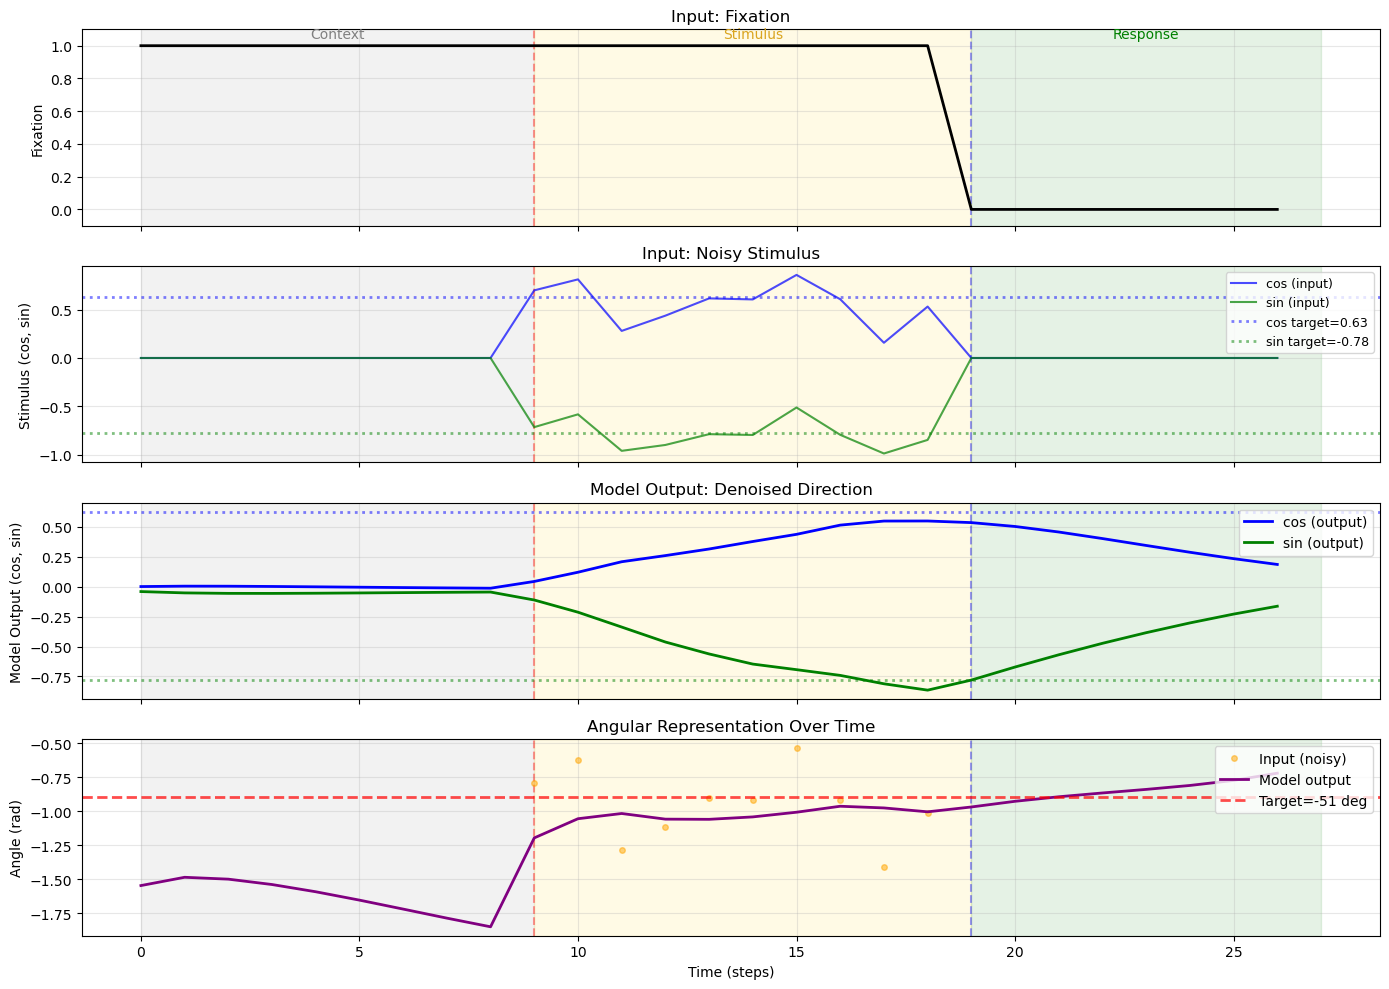

Trial duration breakdown:
  Context phase: 8 timesteps (0 to 7)
  Stimulus phase: 14 timesteps (8 to 21)
  Response phase: 5 timesteps (22 to 26)

Target angle: 0.0 deg
Model output:  -2.9 deg
Error: 2.97 deg


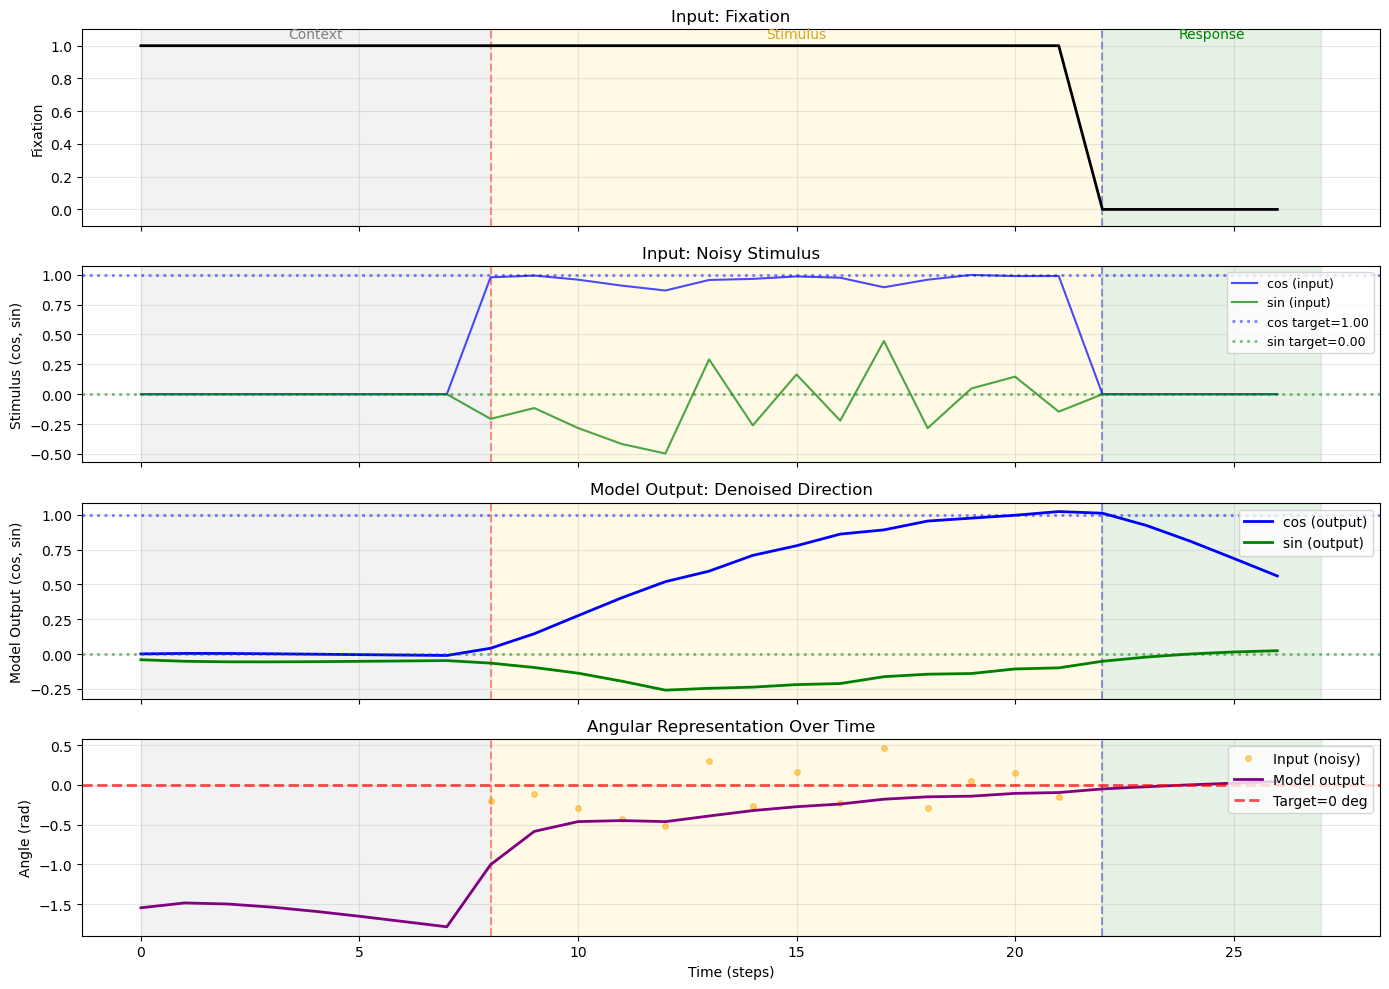

Trial duration breakdown:
  Context phase: 5 timesteps (0 to 4)
  Stimulus phase: 10 timesteps (5 to 14)
  Response phase: 8 timesteps (15 to 22)

Target angle: 156.7 deg
Model output:  151.8 deg
Error: 4.88 deg


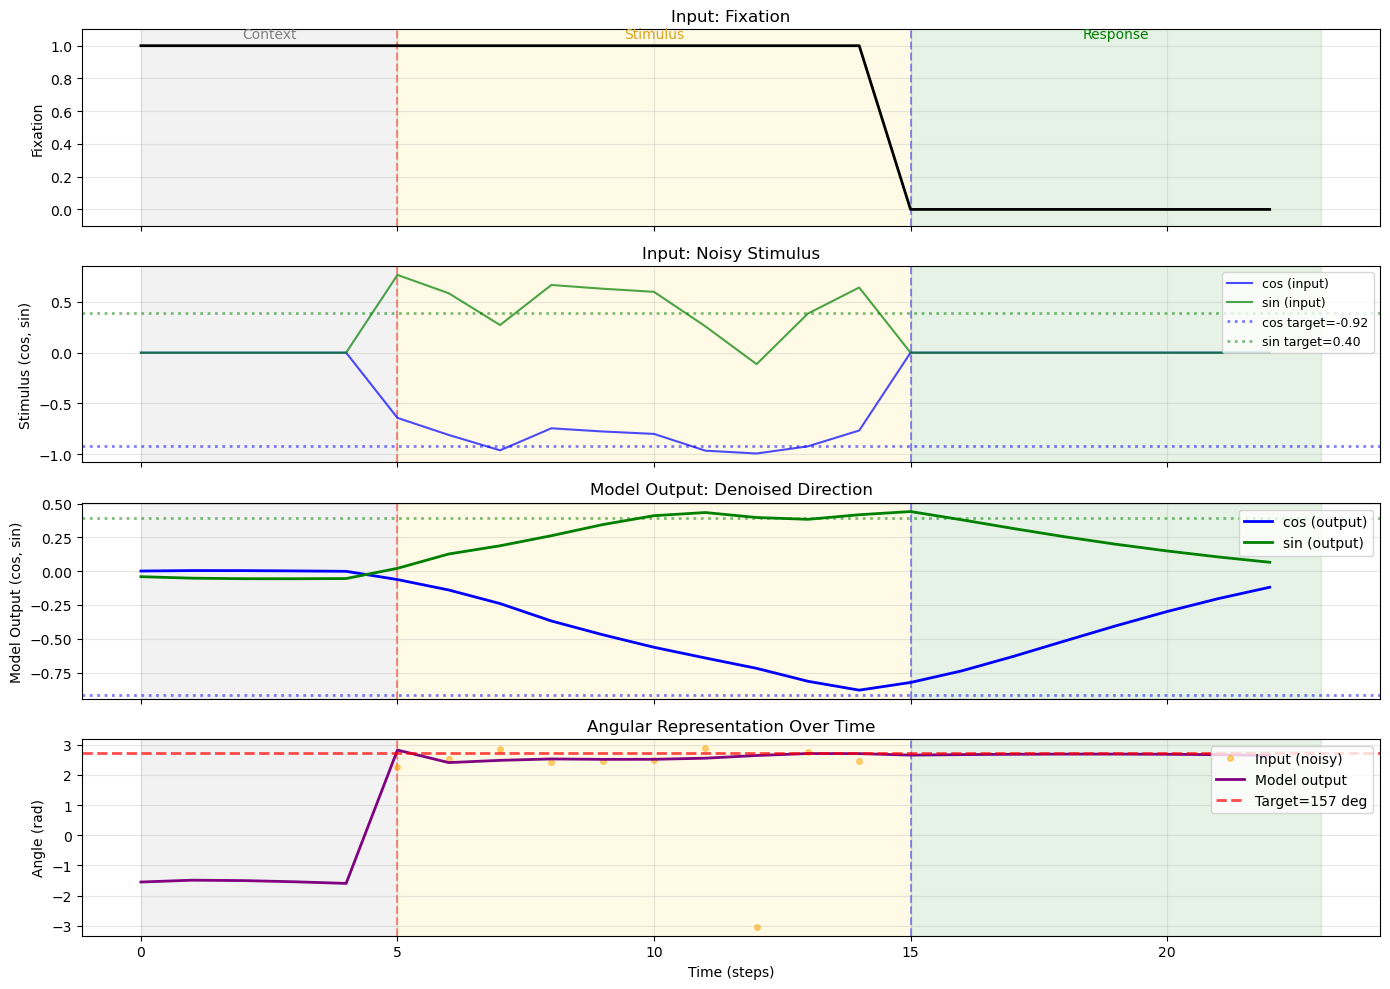

Trial duration breakdown:
  Context phase: 7 timesteps (0 to 6)
  Stimulus phase: 10 timesteps (7 to 16)
  Response phase: 6 timesteps (17 to 22)

Target angle: -57.6 deg
Model output:  -65.4 deg
Error: 7.75 deg


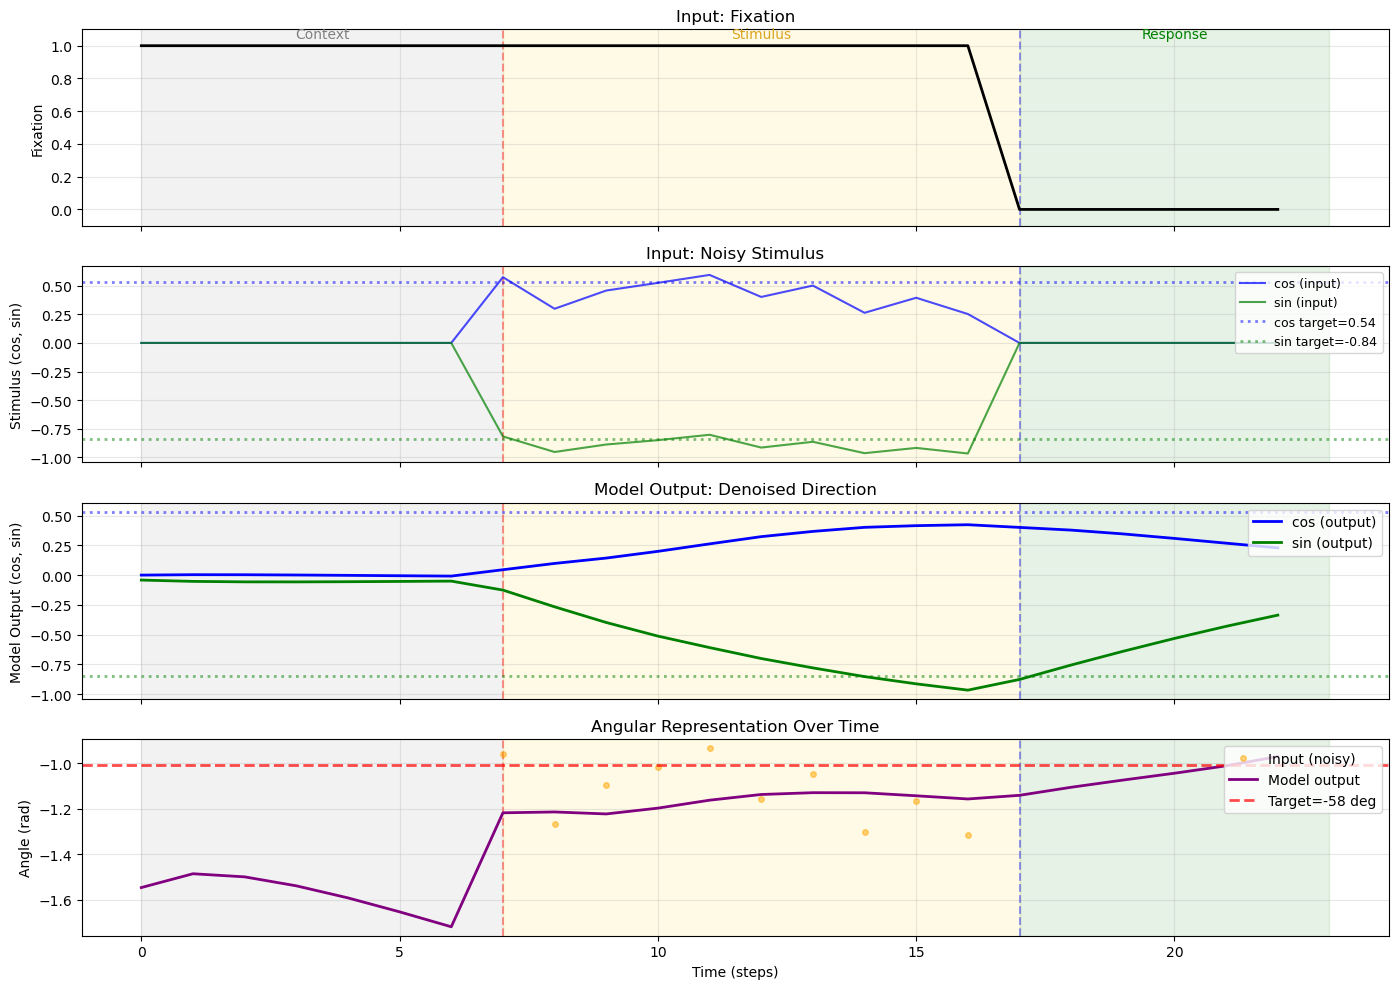

Trial duration breakdown:
  Context phase: 8 timesteps (0 to 7)
  Stimulus phase: 14 timesteps (8 to 21)
  Response phase: 7 timesteps (22 to 28)

Target angle: -79.3 deg
Model output:  -76.9 deg
Error: 2.44 deg


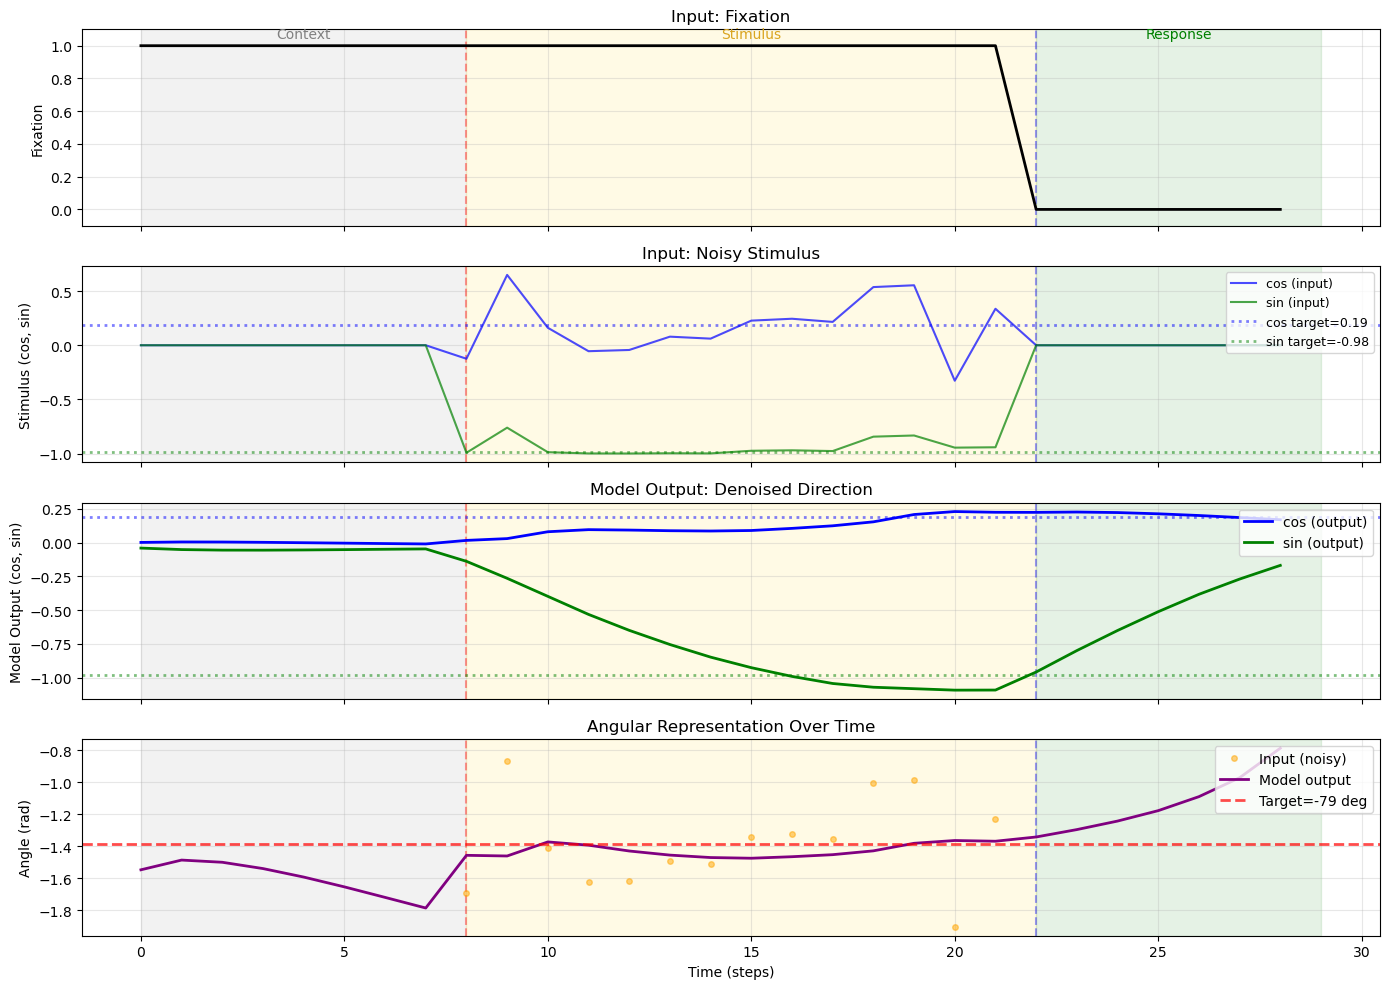

Trial duration breakdown:
  Context phase: 7 timesteps (0 to 6)
  Stimulus phase: 10 timesteps (7 to 16)
  Response phase: 9 timesteps (17 to 25)

Target angle: 45.2 deg
Model output:  35.7 deg
Error: 9.53 deg


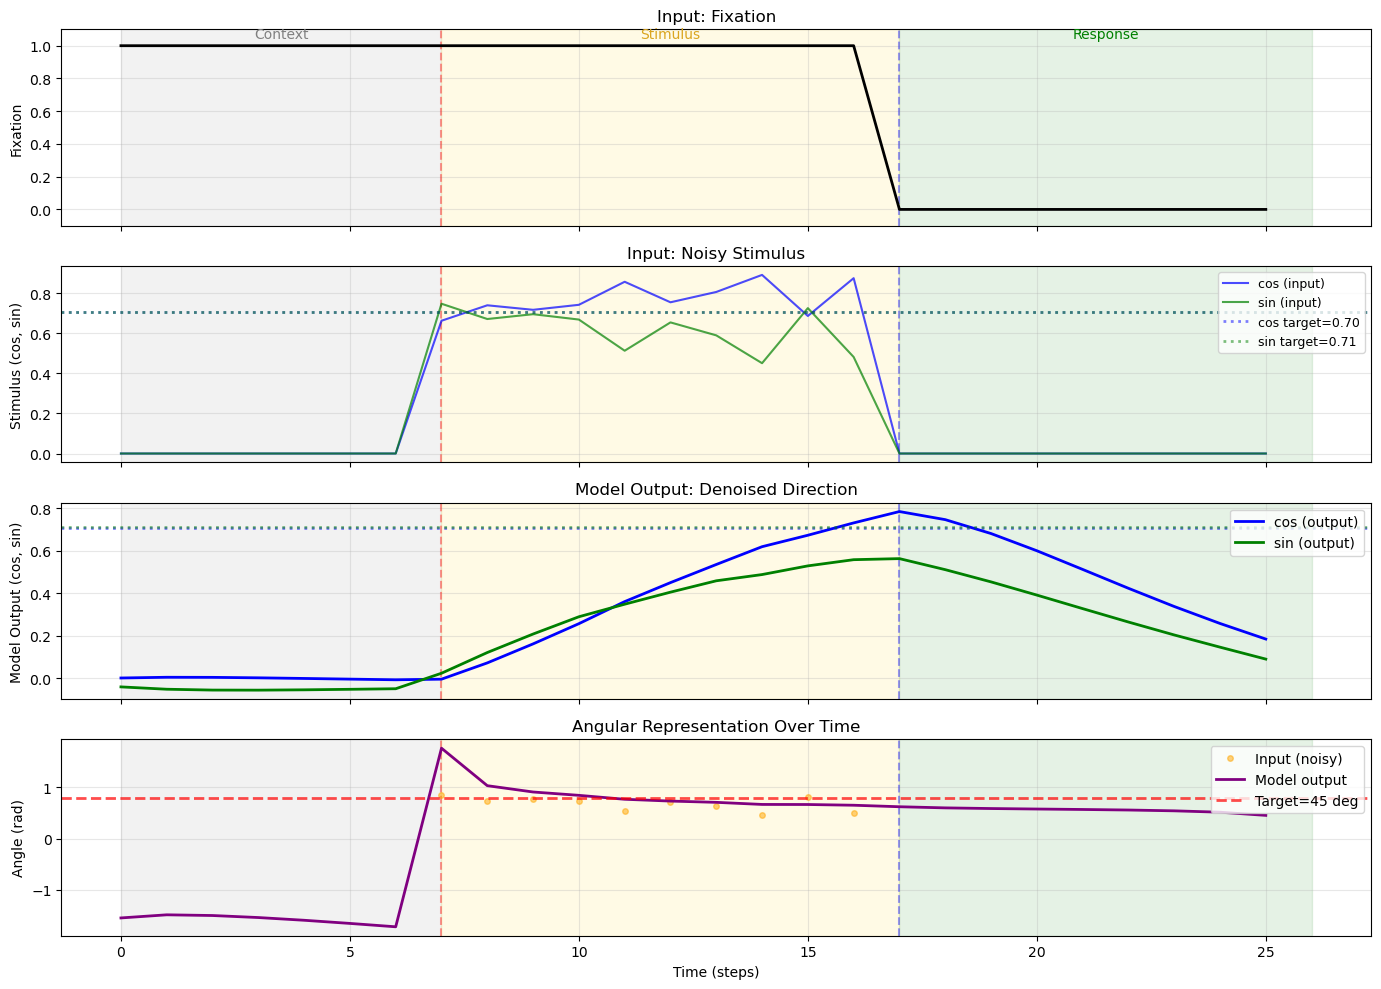

Trial duration breakdown:
  Context phase: 9 timesteps (0 to 8)
  Stimulus phase: 13 timesteps (9 to 21)
  Response phase: 7 timesteps (22 to 28)

Target angle: 55.8 deg
Model output:  58.3 deg
Error: 2.43 deg


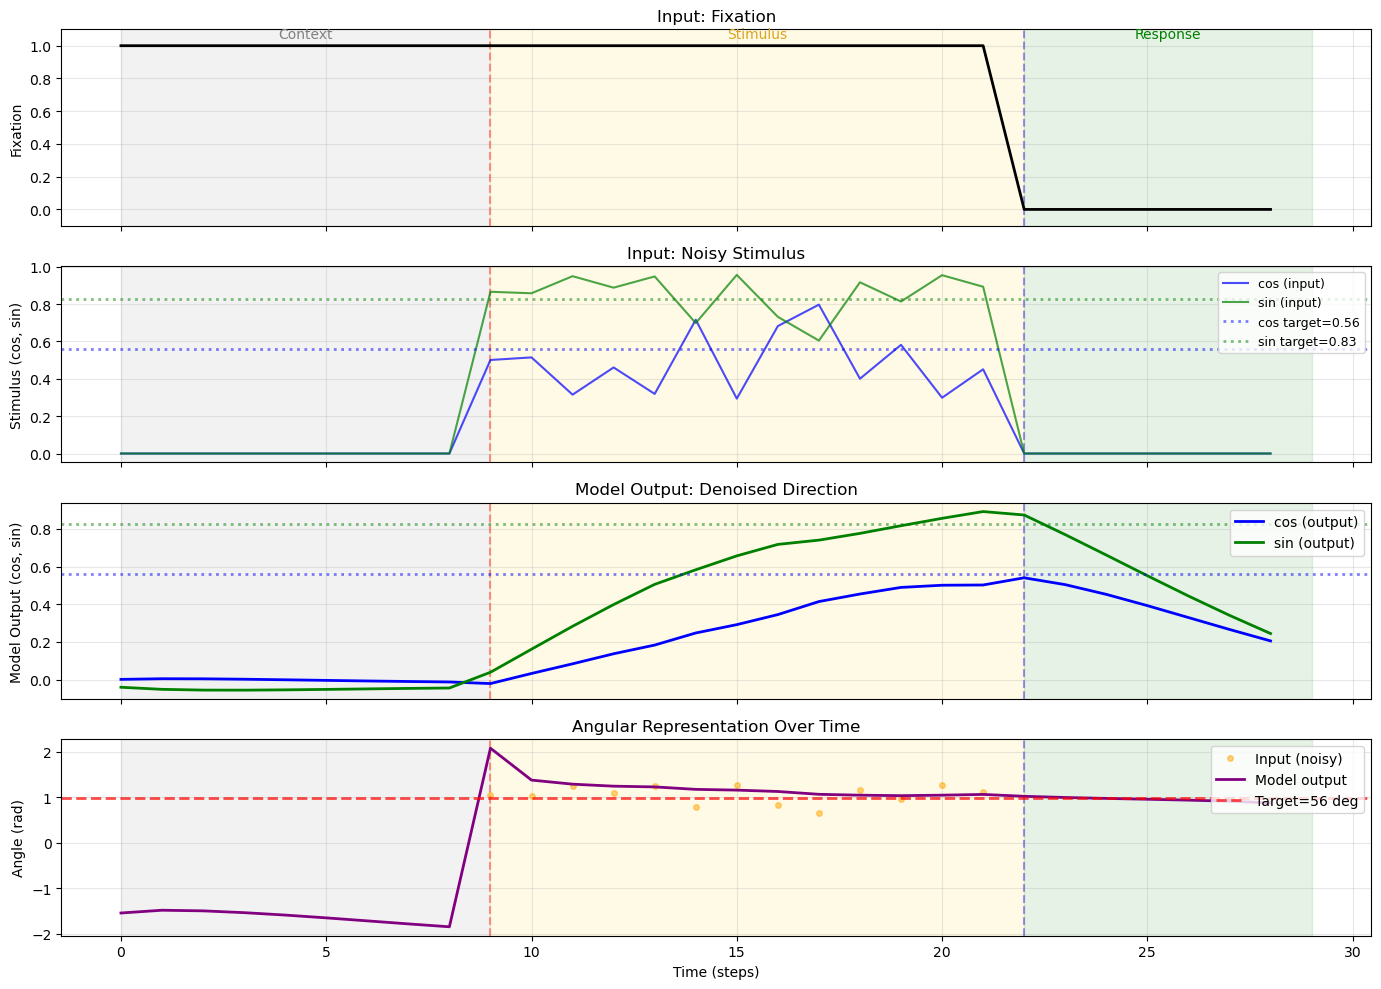

Trial duration breakdown:
  Context phase: 8 timesteps (0 to 7)
  Stimulus phase: 12 timesteps (8 to 19)
  Response phase: 8 timesteps (20 to 27)

Target angle: 111.5 deg
Model output:  108.5 deg
Error: 3.06 deg


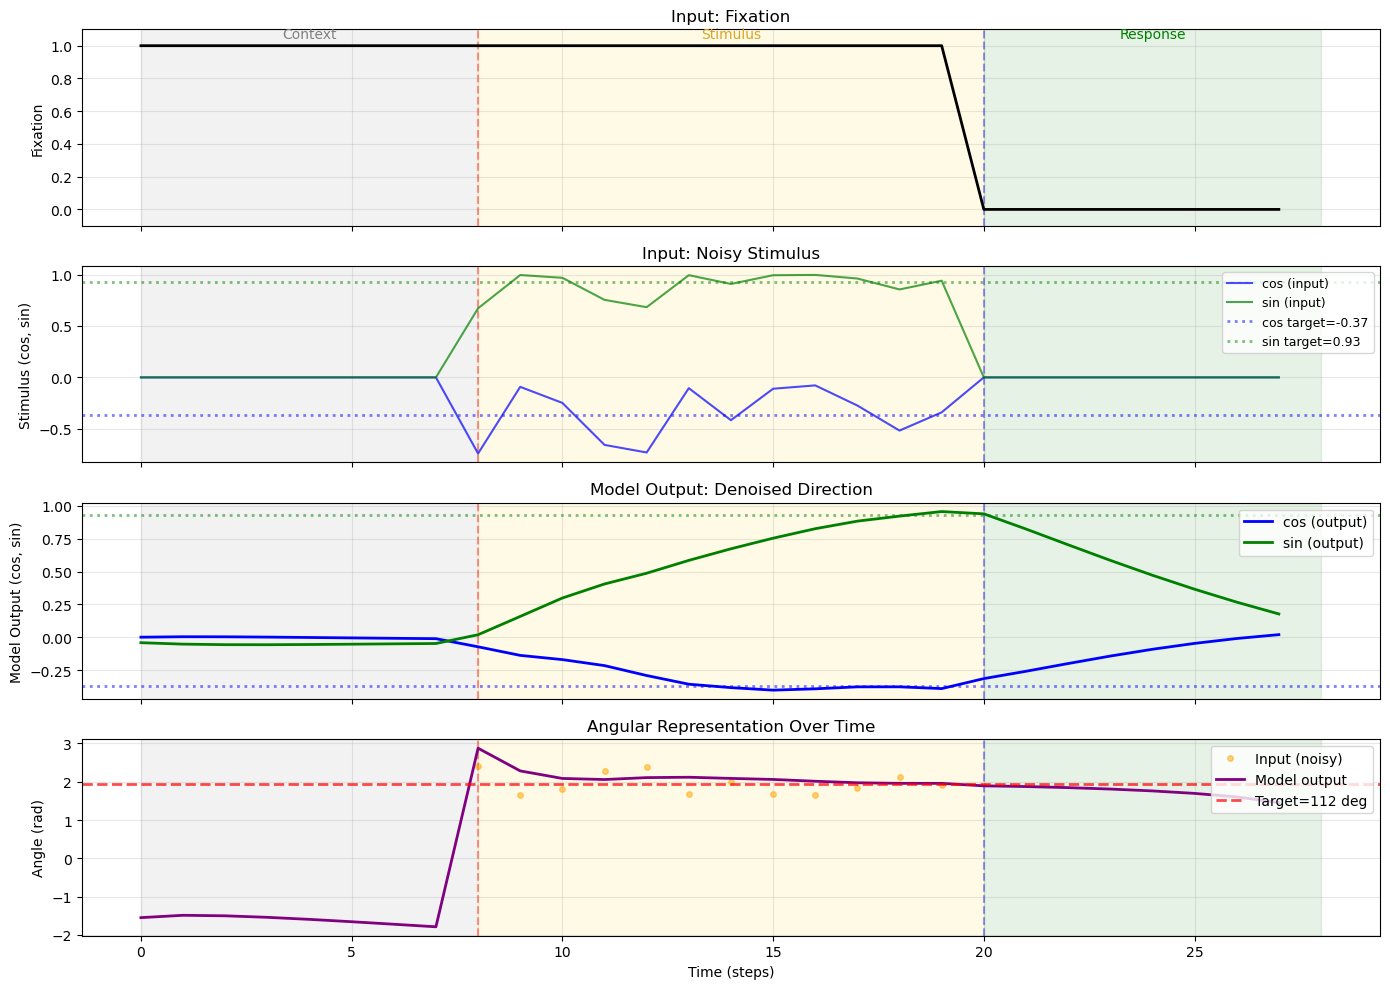

Trial duration breakdown:
  Context phase: 5 timesteps (0 to 4)
  Stimulus phase: 10 timesteps (5 to 14)
  Response phase: 8 timesteps (15 to 22)

Target angle: 148.3 deg
Model output:  147.0 deg
Error: 1.36 deg


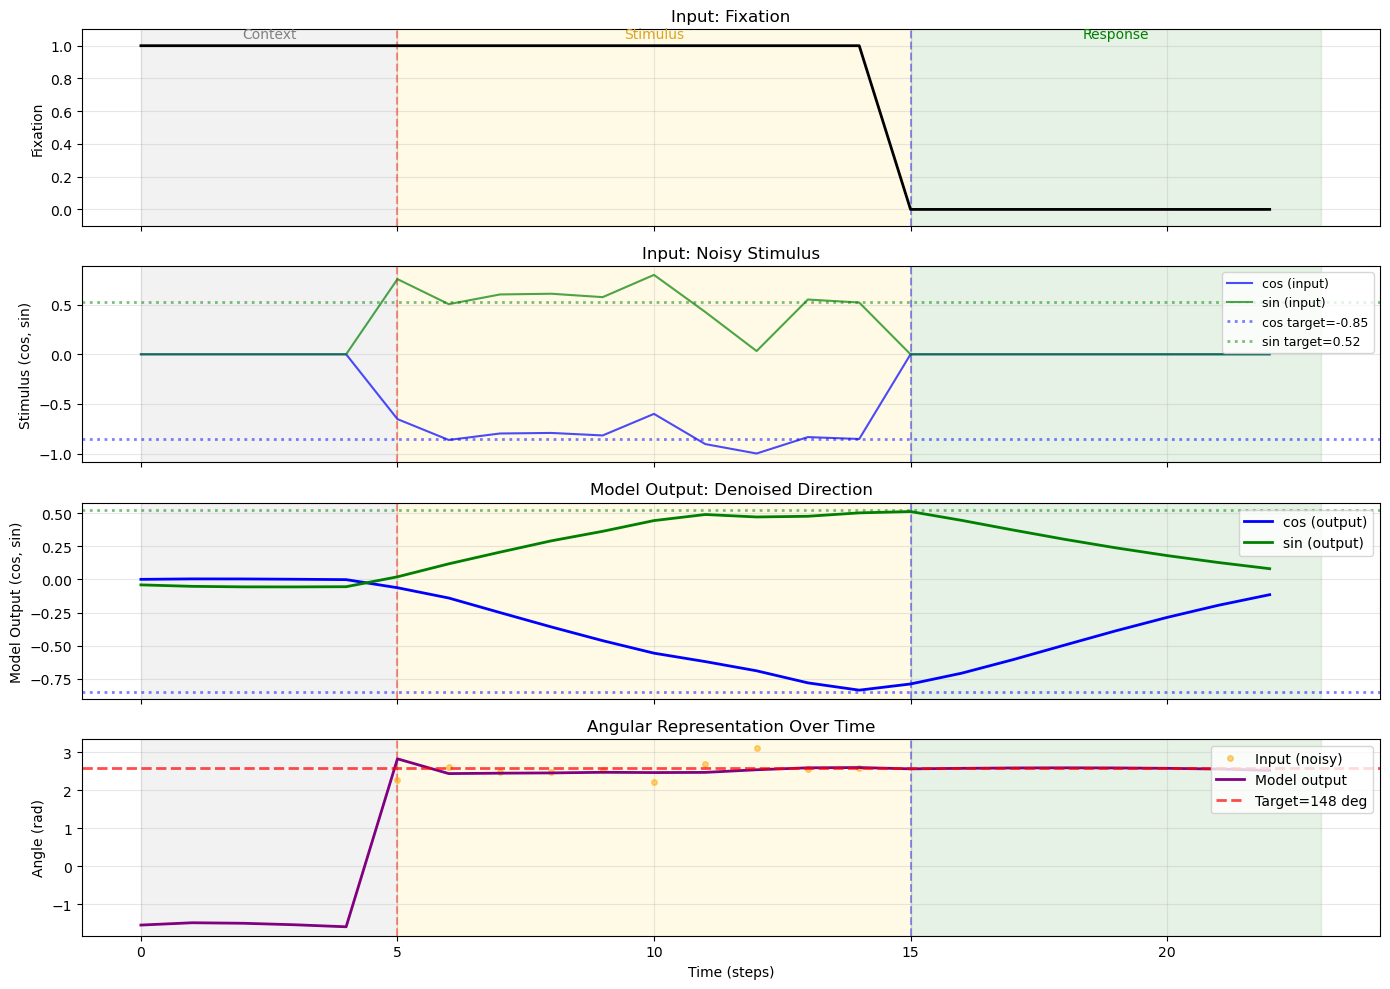


Seed | Error (deg) | Pass (<8 deg)?
----------------------------------------
    0 |       4.41  | PASS
    1 |       2.97  | PASS
    2 |       4.88  | PASS
    3 |       7.75  | PASS
   42 |       2.44  | PASS
   70 |       9.53  | FAIL
   80 |       2.43  | PASS
   90 |       3.06  | PASS
  100 |       1.36  | PASS

Accuracy: 8/9 = 89%


In [12]:
# Summary of errors across seeds
seeds = [0, 1, 2, 3, 42, 70, 80, 90, 100]
errors = []
for seed in seeds:
    fig, info = visualize_single_trial(model, tasks[0], device=device, seed=seed)
    errors.append(info['angle_error_deg'])
    plt.show()

print("\nSeed | Error (deg) | Pass (<8 deg)?")
print("-" * 40)
for s, e in zip(seeds, errors):
    status = "PASS" if e < 8 else "FAIL"
    print(f"  {s:>3} | {e:>10.2f}  | {status}")
print(f"\nAccuracy: {sum(1 for e in errors if e < 8)}/{len(errors)} = {sum(1 for e in errors if e < 8)/len(errors)*100:.0f}%")

In [13]:
# Load
#model, optimizer = load_model('checkpoints/11_tasks_model_M64_L4_2.pt', device=device)

In [14]:
from rnn_model import evaluate_model
from rnn_model import get_latent_states
from rnn_model import run_test_evaluation

In [15]:
# Diagnostic: test model accuracy the SAME way training does
model.eval()
correct = 0
total = 0
threshold = 8 * np.pi / 180

for inputs, targets, masks, task_ids in train_loader:
    inputs = inputs.to(device)
    targets = targets.to(device)
    masks = masks.to(device)
    
    with torch.no_grad():
        outputs = model(inputs)
    
    targets_exp = targets  # already (batch, T, 3) from collate_fn
    pred_angle = torch.atan2(outputs[..., 2], outputs[..., 1])
    target_angle = torch.atan2(targets_exp[..., 2], targets_exp[..., 1])
    angle_error = torch.abs(pred_angle - target_angle)
    angle_error = torch.min(angle_error, 2 * np.pi - angle_error)
    
    mask_bool = masks > 0
    for i in range(inputs.shape[0]):
        masked_error = angle_error[i][mask_bool[i]]
        if masked_error.numel() > 0:
            is_correct = (masked_error < threshold).all().item()
            correct += is_correct
            total += 1

print(f"Post-training accuracy (same as train loop): {correct}/{total} = {correct/total*100:.1f}%")

# Also test a single trial directly
task = tasks[0]
np.random.seed(42)
torch.manual_seed(42)
inp, tgt, msk = task()
with torch.no_grad():
    out = model(inp.unsqueeze(0).to(device))
out = out.squeeze(0)
mask_idx = torch.where(msk > 0)[0]
print(f"\nSingle trial (seed=42):")
print(f"  Input shape: {inp.shape}")
print(f"  Model input_dim: {model.input_dim}")
print(f"  Output at mask idx {mask_idx}: {out[mask_idx[0]].cpu().numpy()}")
print(f"  Target: {tgt.numpy()}")

Post-training accuracy (same as train loop): 276/300 = 92.0%

Single trial (seed=42):
  Input shape: torch.Size([29, 7])
  Model input_dim: 7
  Output at mask idx tensor([22]): [ 0.00413363  0.22325641 -0.9575025 ]
  Target: [ 0.          0.18547384 -0.9826492 ]


In [ ]:
n_test_trials=999
# Create test dataset
test_dataset = MultiTaskDataset_v2(tasks, n_trials=n_test_trials)
test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False,
    collate_fn=collate_fn
)

In [20]:
inputs, targets, masks, task_ids = next(iter(train_loader))

In [31]:
# Get test accuracies
print("Evaluating test accuracy...")
test_accuracies = evaluate_model(model, test_loader, device, task_names, task_thresholds={0: 8*np.pi/180})
print("\nTest Accuracies:")
for task_id, acc in test_accuracies.items():
    print(f"  {task_names[task_id]}: {acc:.2%}")

# latent_states, trial_info = get_latent_states(model, test_loader, device, task_names)

Evaluating test accuracy...

Test Accuracies:
  NoiseCleaner: 91.49%


In [ ]:
latent_states[0][0].shape

In [ ]:
import analysis_functions as af
import importlib
importlib.reload(af)
import numpy as np

In [ ]:
# Compute distributions for all tasks
distributions = {}
for task_id in range(len(task_names)):
    if latent_states[task_id].shape[0] > 0:
        distributions[task_id] = af.bitcode_distribution(latent_states[task_id], model.L)

# Align distributions
aligned_matrix, bitcode_labels = af.align_bitcode_distributions(distributions)


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import torch


def visualize_single_trial(model, task, device='cpu', seed=None):
    """
    Visualize a single trial from a task showing inputs, outputs, and targets
    across different phases.

    Parameters:
    -----------
    model : trained PLRNN model
    task : CognitiveTask instance (e.g., NoiseCleaner)
    device : torch device
    seed : random seed for reproducibility
    """
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)

    # Generate a single trial
    inputs, targets, mask = task()

    # Add batch dimension
    inputs_batch = inputs.unsqueeze(0).to(device)  # [1, T, input_dim]

    # Run through model
    model.eval()
    with torch.no_grad():
        outputs, _, _ = model(inputs_batch)  # [1, T, N]

    # Remove batch dimension
    inputs = inputs.cpu().numpy()
    outputs = outputs.squeeze(0).cpu().numpy()
    targets = targets.cpu().numpy()
    mask = mask.cpu().numpy()

    # Find phase boundaries by examining the input pattern
    T_total = inputs.shape[0]

    # Context phase: fixation only (no stimulus)
    # Stimulus phase: fixation + stimulus (cos, sin != 0)
    # Response phase: no fixation

    fixation = inputs[:, 0]
    stimulus_present = np.abs(inputs[:, 1]) + np.abs(inputs[:, 2]) > 0.01

    # Find phase boundaries
    context_end = np.where(stimulus_present)[0][0] if np.any(stimulus_present) else 0
    stim_end = np.where(mask > 0)[0][0] if np.any(mask > 0) else T_total

    T_context = context_end
    T_stim = stim_end - context_end
    T_response = T_total - stim_end

    print(f"Trial duration breakdown:")
    print(f"  Context phase: {T_context} timesteps (indices 0-{T_context-1})")
    print(f"  Stimulus phase: {T_stim} timesteps (indices {T_context}-{stim_end-1})")
    print(f"  Response phase: {T_response} timesteps (indices {stim_end}-{T_total-1})")
    print(f"  Total: {T_total} timesteps")

    # Compute true direction from noisy samples (average)
    if T_stim > 0:
        stim_cos = inputs[T_context:stim_end, 1]
        stim_sin = inputs[T_context:stim_end, 2]
        avg_cos = np.mean(stim_cos)
        avg_sin = np.mean(stim_sin)
        empirical_angle = np.arctan2(avg_sin, avg_cos)
    else:
        empirical_angle = 0

    # Target angle
    target_angle = np.arctan2(targets[1], targets[2])

    # Model output angle at response
    if T_response > 0:
        output_cos = outputs[stim_end, 1]
        output_sin = outputs[stim_end, 2]
        model_angle = np.arctan2(output_sin, output_cos)

        # Compute error
        angle_error = np.abs(np.angle(np.exp(1j * (model_angle - target_angle))))
        angle_error_deg = np.degrees(angle_error)
    else:
        model_angle = 0
        angle_error_deg = 0

    print(f"\nAngles (in radians):")
    print(f"  Target (true): {target_angle:.3f}")
    print(f"  Empirical (from noisy samples): {empirical_angle:.3f}")
    print(f"  Model output at response: {model_angle:.3f}")
    print(f"  Angular error: {angle_error_deg:.2f} degrees")

    # Create figure
    fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
    time = np.arange(T_total)

    # Subplot 1: Fixation channel
    ax = axes[0]
    ax.plot(time, fixation, 'k-', linewidth=2, label='Fixation')
    ax.axvline(T_context, color='red', linestyle='--', alpha=0.5, label='Context end')
    ax.axvline(stim_end, color='blue', linestyle='--', alpha=0.5, label='Stimulus end')
    ax.set_ylabel('Fixation', fontsize=12)
    ax.set_ylim([-0.1, 1.1])
    ax.legend(loc='upper right')
    ax.set_title('Input: Fixation Channel', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Subplot 2: Stimulus channels (cos, sin)
    ax = axes[1]
    ax.plot(time, inputs[:, 1], 'b-', linewidth=1.5, label='cos (input)', alpha=0.7)
    ax.plot(time, inputs[:, 2], 'g-', linewidth=1.5, label='sin (input)', alpha=0.7)
    ax.axhline(targets[1], color='b', linestyle=':', linewidth=2, label=f'cos (target={targets[1]:.2f})', alpha=0.5)
    ax.axhline(targets[2], color='g', linestyle=':', linewidth=2, label=f'sin (target={targets[2]:.2f})', alpha=0.5)
    ax.axvline(T_context, color='red', linestyle='--', alpha=0.5)
    ax.axvline(stim_end, color='blue', linestyle='--', alpha=0.5)
    ax.set_ylabel('Stimulus\n(cos, sin)', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_title('Input: Noisy Stimulus (cos, sin)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Subplot 3: Model outputs (cos, sin)
    ax = axes[2]
    ax.plot(time, outputs[:, 1], 'b-', linewidth=2, label='cos (output)')
    ax.plot(time, outputs[:, 2], 'g-', linewidth=2, label='sin (output)')
    ax.axhline(targets[1], color='b', linestyle=':', linewidth=2, alpha=0.5)
    ax.axhline(targets[2], color='g', linestyle=':', linewidth=2, alpha=0.5)
    ax.axvline(T_context, color='red', linestyle='--', alpha=0.5)
    ax.axvline(stim_end, color='blue', linestyle='--', alpha=0.5)
    ax.set_ylabel('Model Output\n(cos, sin)', fontsize=12)
    ax.legend(loc='upper right')
    ax.set_title('Model Output: Denoised Direction', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Subplot 4: Fixation output
    ax = axes[3]
    ax.plot(time, outputs[:, 0], 'k-', linewidth=2, label='Fixation (output)')
    ax.axhline(targets[0], color='k', linestyle=':', linewidth=2, label=f'Fixation (target={targets[0]:.1f})', alpha=0.5)
    ax.axvline(T_context, color='red', linestyle='--', alpha=0.5)
    ax.axvline(stim_end, color='blue', linestyle='--', alpha=0.5)
    ax.set_ylabel('Fixation\nOutput', fontsize=12)
    ax.legend(loc='upper right')
    ax.set_title('Model Output: Fixation', fontsize=14, fontweight='bold')
    ax.set_ylim([-0.1, 1.1])
    ax.grid(True, alpha=0.3)

    # Subplot 5: Angular representation over time
    ax = axes[4]

    # Compute angles over time for input and output
    input_angles = np.arctan2(inputs[:, 2], inputs[:, 1])
    output_angles = np.arctan2(outputs[:, 2], outputs[:, 1])

    # Only plot where stimulus is present (avoid meaningless angles)
    stim_mask = stimulus_present.copy()
    input_angles_masked = input_angles.copy()
    input_angles_masked[~stim_mask] = np.nan

    ax.plot(time, input_angles_masked, 'o', color='orange', markersize=4, alpha=0.5, label='Input angle (noisy)')
    ax.plot(time, output_angles, 'purple', linewidth=2, label='Output angle')
    ax.axhline(target_angle, color='red', linestyle='--', linewidth=2, label=f'Target angle={target_angle:.2f}', alpha=0.7)
    ax.axvline(T_context, color='red', linestyle='--', alpha=0.5)
    ax.axvline(stim_end, color='blue', linestyle='--', alpha=0.5)
    ax.set_ylabel('Angle (rad)', fontsize=12)
    ax.set_xlabel('Time (steps)', fontsize=12)
    ax.legend(loc='upper right')
    ax.set_title('Angular Representation Over Time', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Add phase labels
    for ax in axes:
        # Add phase backgrounds
        ax.axvspan(0, T_context, alpha=0.1, color='gray', label='Context')
        ax.axvspan(T_context, stim_end, alpha=0.1, color='yellow', label='Stimulus')
        ax.axvspan(stim_end, T_total, alpha=0.1, color='green', label='Response')

    plt.tight_layout()

    return fig, {
        'T_context': T_context,
        'T_stim': T_stim,
        'T_response': T_response,
        'target_angle': target_angle,
        'model_angle': model_angle,
        'angle_error_deg': angle_error_deg,
        'inputs': inputs,
        'outputs': outputs,
        'targets': targets
    }


def analyze_phase_outputs(model, task, device='cpu', n_trials=10):
    """
    Analyze model outputs across phases for multiple trials.
    Shows statistics about when the model starts producing the correct output.
    """
    model.eval()

    phase_stats = {
        'context_errors': [],
        'stim_errors': [],
        'response_errors': []
    }

    for i in range(n_trials):
        # Generate trial
        inputs, targets, mask = task()
        inputs_batch = inputs.unsqueeze(0).to(device)

        # Run model
        with torch.no_grad():
            outputs, _, _ = model(inputs_batch)

        outputs = outputs.squeeze(0).cpu().numpy()
        targets = targets.cpu().numpy()
        inputs = inputs.cpu().numpy()

        # Find phases
        fixation = inputs[:, 0]
        stimulus_present = np.abs(inputs[:, 1]) + np.abs(inputs[:, 2]) > 0.01

        context_end = np.where(stimulus_present)[0][0] if np.any(stimulus_present) else 0
        stim_end = np.where(mask > 0)[0][0] if np.any(mask > 0) else inputs.shape[0]

        # Target angle
        target_angle = np.arctan2(targets[1], targets[2])

        # Compute errors at different phases
        if context_end > 0:
            # During context (before seeing stimulus)
            out_angle = np.arctan2(outputs[context_end-1, 2], outputs[context_end-1, 1])
            error = np.abs(np.angle(np.exp(1j * (out_angle - target_angle))))
            phase_stats['context_errors'].append(np.degrees(error))

        # During stimulus (middle of stim phase)
        mid_stim = (context_end + stim_end) // 2
        out_angle = np.arctan2(outputs[mid_stim, 2], outputs[mid_stim, 1])
        error = np.abs(np.angle(np.exp(1j * (out_angle - target_angle))))
        phase_stats['stim_errors'].append(np.degrees(error))

        # At response
        out_angle = np.arctan2(outputs[stim_end, 2], outputs[stim_end, 1])
        error = np.abs(np.angle(np.exp(1j * (out_angle - target_angle))))
        phase_stats['response_errors'].append(np.degrees(error))

    # Print statistics
    print(f"\nPhase-wise angular errors (n={n_trials} trials):")
    print(f"  Context phase (end):    {np.mean(phase_stats['context_errors']):.2f}° ± {np.std(phase_stats['context_errors']):.2f}°")
    print(f"  Stimulus phase (mid):   {np.mean(phase_stats['stim_errors']):.2f}° ± {np.std(phase_stats['stim_errors']):.2f}°")
    print(f"  Response phase (start): {np.mean(phase_stats['response_errors']):.2f}° ± {np.std(phase_stats['response_errors']):.2f}°")

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    phases = ['Context\n(end)', 'Stimulus\n(mid)', 'Response\n(start)']
    means = [
        np.mean(phase_stats['context_errors']),
        np.mean(phase_stats['stim_errors']),
        np.mean(phase_stats['response_errors'])
    ]
    stds = [
        np.std(phase_stats['context_errors']),
        np.std(phase_stats['stim_errors']),
        np.std(phase_stats['response_errors'])
    ]

    colors = ['gray', 'orange', 'green']
    ax.bar(phases, means, yerr=stds, color=colors, alpha=0.7, capsize=5)
    ax.set_ylabel('Angular Error (degrees)', fontsize=12)
    ax.set_xlabel('Phase', fontsize=12)
    ax.set_title('Model Performance Across Trial Phases', fontsize=14, fontweight='bold')
    ax.axhline(8, color='red', linestyle='--', label='Threshold (8°)', linewidth=2)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    return fig, phase_stats
